In [51]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import scipy
import pickle
import os
path = os.getcwd()

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [52]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:,i_time] = maxI_
    return control_

def set_init(init_v_):
    init_vars = aln.init_vars
    for i in range(len(init_vars)):
        if aln.params[init_vars[i]].size == 1:
            aln.params[init_vars[i]][0] = init_v_[i]
        else:
            aln.params[init_vars[i]][0,-1] = init_v_[i]

In [53]:
aln = ALNModel()

print(aln.params["mufe_init"])

aln.params['duration'] = 1000.

control0 = aln.getZeroControl()

aln.params.ext_exc_current = 1.0
aln.params.ext_inh_current = 1.0

aln.params.signalV = 0.
aln.params.de = 0.0
aln.params.di = 0.0

aln.params.cee = 0.0
aln.params.cei = 0.
aln.params.cie = 0.
aln.params.cii = 0.
aln.params.Ke = 0.
aln.params.Ki = 0.
aln.params.Jee = 1e-30
aln.params.Jei = 1e-30
aln.params.Jie = 1e-30
aln.params.Jii = 1e-30

# NO ADAPTATION
aln.params.IA_init = np.array([0.])

aln.params.mue_ext_mean = 0.0
aln.params.mui_ext_mean = 0.0

state = aln.getZeroState()
fullState = aln.getZeroFullState()
aln.run(control = control0)

#plt.plot(aln.t, aln.rates_exc[0,:])
#plt.plot(aln.t, aln.rates_inh[0,:])

output = aln.output_vars

for i in range(len(output)):
    state[:,i,:] = aln[output[i]][:,:]

state_vars = aln.state_vars
init_vars = aln.init_vars

vars_init = np.zeros(( len(state_vars) ))
vars_init[0] = np.array( [[0.]])
vars_init[1] = np.array( [[0.]])
vars_init[2] = np.array( [2.])
vars_init[3] = np.array( [2.])

steady_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    #print(state_vars[i], aln.state[state_vars[i]].shape)
    #plt.plot(aln.t, aln.state[state_vars[i]][0,:])
    #plt.show()
    steady_state_vars[i] = aln.state[state_vars[i]][0,-1]

[0.6486]


In [54]:
dur = 0.4
dur_pre = 0.0
dur_post = 0
aln.params.duration = dur

control0 = aln.getZeroControl()
target = aln.getZeroTarget()

c_scheme = np.zeros((len(aln.output_vars), len(aln.output_vars) ))
c_scheme[0,0] = 1.
u_mat = np.identity(aln.params['N'])
u_scheme = np.array([[1, 0], [0, 0]])

max_it = 100
tol = 1e-16
incl_step = int(1. + aln.params.duration/aln.params.dt)
start_step = 1000.
test_step = 1e-12

In [55]:
set_init(vars_init)
                
aln.params.duration = dur + dur_pre
cntrl_zeros_pre = int(dur_pre / aln.params.dt)
        
control1 = aln.getZeroControl()
control1[:,0,:] += 1.

aln.run(control=control1)
target[:,0,:] = aln.rates_exc[:,cntrl_zeros_pre:]
target[:,1,:] = aln.rates_inh[:,cntrl_zeros_pre:]

print("exc rates = ", aln.rates_exc[0,:])
print("inh rates = ", aln.rates_inh[0,:])

exc rates =  [ 0.     59.2229 59.2229 59.2229 59.2229]
inh rates =  [ 0.     59.2229 55.366  52.2206 49.5749]


In [57]:
############# A2
cost.setParams(1.0, 1.0, 0.)
max_cntrl = 1000. * 5.

aln.params.duration = dur
set_init(vars_init)
control2 = aln.getZeroControl()
#control2[:,0,1] += 1.

max_it = 5
    
A2_bestControlA, A2_bestStateA, A2_costA, A2_runtimeA = aln.A2(control2, target, max_iteration_ = max_it,
        tolerance_ = tol, test_step_ = test_step, max_control_ = max_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

set cost params
start ind =  1
RUN  0 , total integrated cost:  7.8495043842385055
RUN  1 , total integrated cost:  2.1428992057609193
RUN  2 , total integrated cost:  0.2209216452335142
RUN  3 , total integrated cost:  0.15923402633809233
RUN  4 , total integrated cost:  0.1485538258602057
3  cost =  [0.     0.4961 0.5146 0.4222 0.0385]
RUN  5 , total integrated cost:  0.14714240219694744
Improved over  5  iterations by  99  percent.


[[[0.     0.9961 1.0144 0.918  0.    ]
  [0.     0.     0.     0.     0.    ]]]


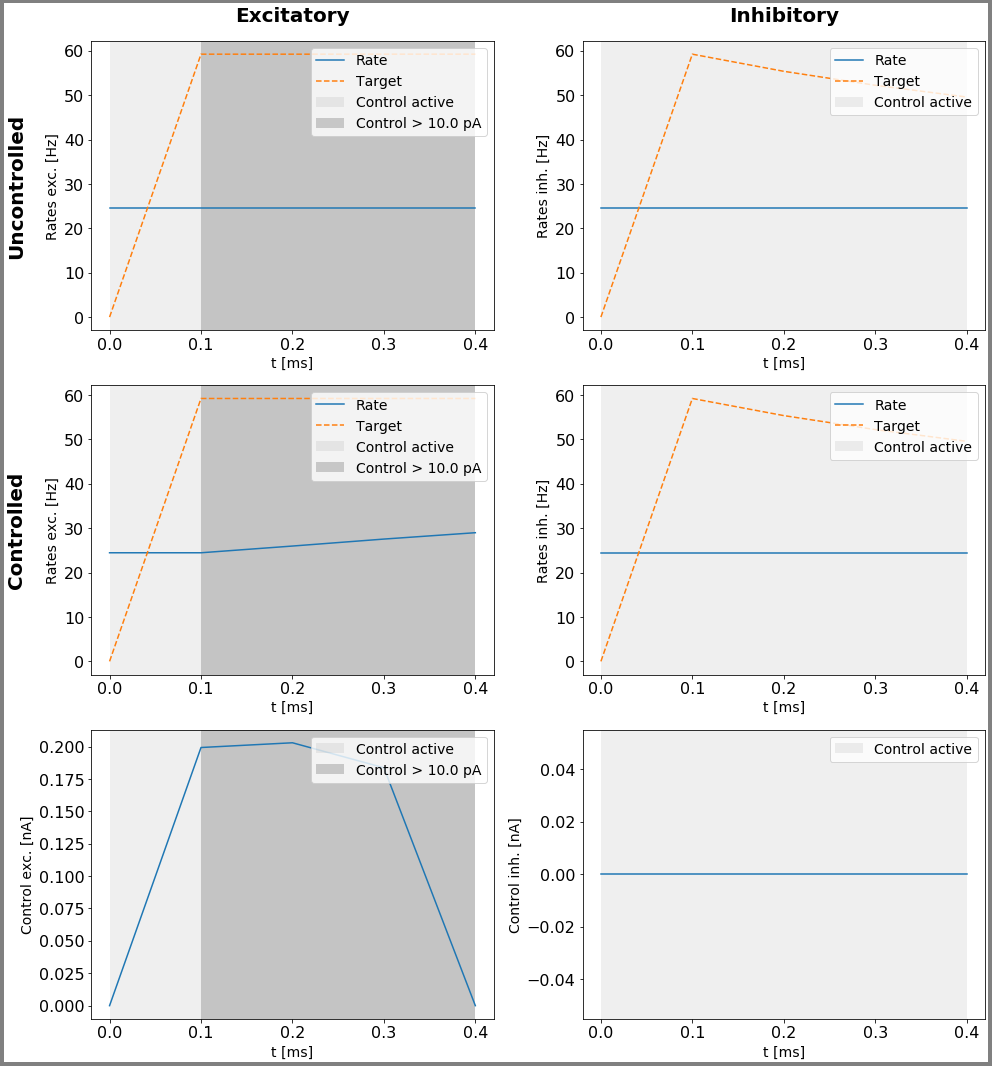

In [58]:
print(A2_bestControlA)
plotFunc.plot_control(aln, A2_bestControlA, dur, dur_pre, dur_post, steady_state_vars, target,
                      path, filename_ = 'a2')

In [71]:
dur = 0.4
dur_pre = 0.0
dur_post = 0.
aln.params.duration = dur

#aln.params.cee = 0.1
#aln.params.Ke = 1000.
#aln.params.Jee = 1.
aln.params.cee = 0.
aln.params.Ke = 0.
aln.params.Jee = 1e-30

cost.setParams(1.0, 0.0, 0.)

max_it = 30
start_step = 1000.

set_init(vars_init)
control2 = aln.getZeroControl()

A1_bestControlA_st, A1_bestStateA_st, A1_costA_st, A1_runtimeA_st = aln.A1(control2, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = None)

set cost params
RUN  0 , total integrated cost =  7.8495043842385055
RUN  1 , total integrated cost =  0.261322783945425
RUN  2 , total integrated cost =  0.06842050168201624
RUN  3 , total integrated cost =  0.02098240962454142
RUN  4 , total integrated cost =  0.007212018096986133
RUN  5 , total integrated cost =  0.0020303105187309146
RUN  6 , total integrated cost =  0.0013003580736991108
RUN  7 , total integrated cost =  0.0008192737448015925
RUN  8 , total integrated cost =  0.00015184490203172177
RUN  9 , total integrated cost =  8.248041402010526e-05
RUN  10 , total integrated cost =  1.9687202350835133e-05
RUN  11 , total integrated cost =  8.788804017776278e-06
RUN  12 , total integrated cost =  2.7741919066959465e-06
RUN  13 , total integrated cost =  9.686913350381404e-07
RUN  14 , total integrated cost =  4.172787701763349e-07
RUN  15 , total integrated cost =  1.08963597675579e-07
RUN  16 , total integrated cost =  5.8791503652862084e-08
RUN  17 , total integrated cost = 

best control =  [[[1. 1. 1. 1. 1.]
  [0. 0. 0. 0. 0.]]]


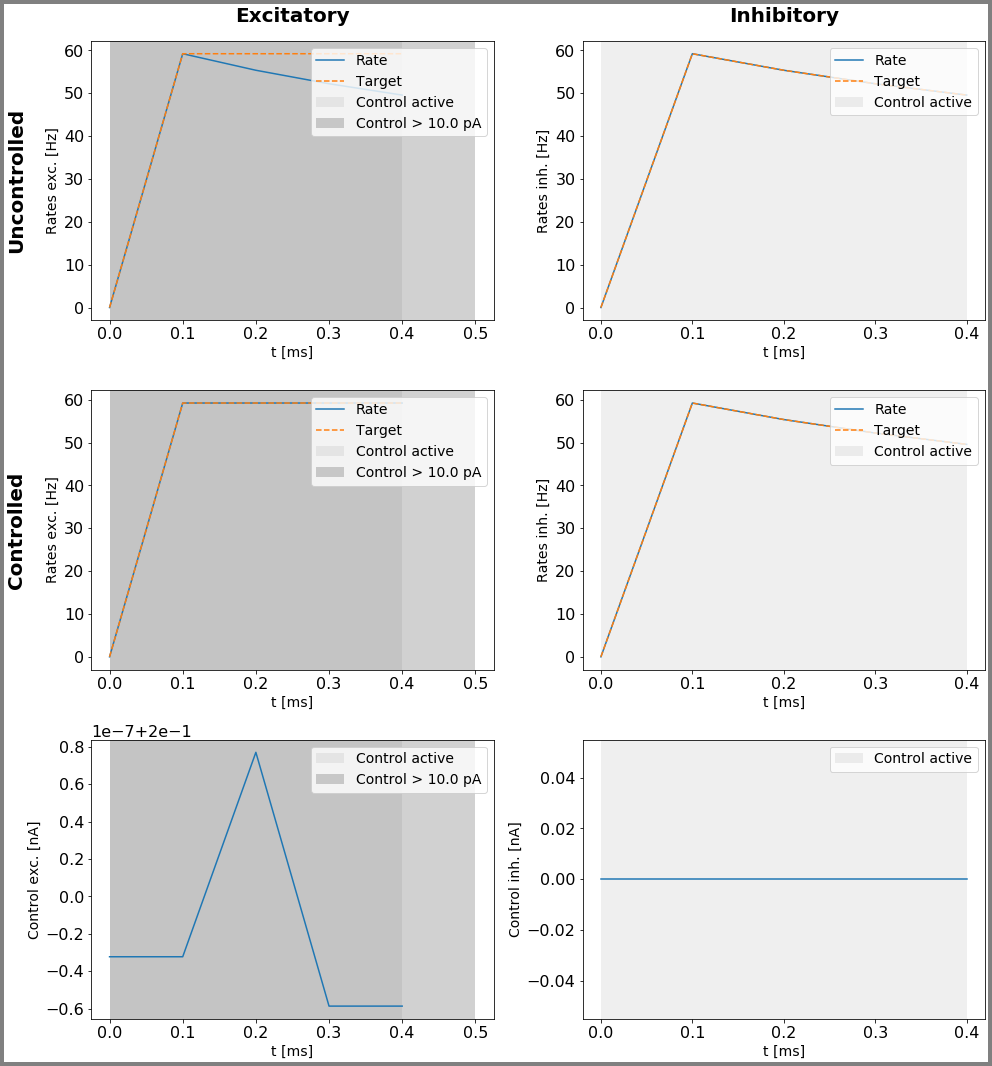

In [68]:
print("best control = ", A1_bestControlA_st)
plotFunc.plot_control(aln, A1_bestControlA_st, dur, dur_pre, dur_post, vars_init, target,
                      path, filename_ = 'a1_st')